# Notebook 05 — Evaluasi Komparatif Semua Skenario V2

Notebook ini mengevaluasi **seluruh skenario model** yang telah dilatih dalam satu eksekusi, kemudian menampilkan perbandingan kinerja secara visual dan menyimpan hasilnya ke CSV.

## Skenario yang Dibandingkan

| Skenario | BSP | Learned Spatial | Temporal Attn |
|---|:---:|:---:|:---:|
| 1 — Baseline | ✗ | ✗ | ✗ |
| 2 — Full Model | ✓ | ✓ | ✓ |
| 3a — Ablasi: Hanya BSP | ✓ | ✗ | ✗ |
| 3b — Ablasi: BSP + Learned | ✓ | ✓ | ✗ |
| 3c — Ablasi: BSP + Temporal | ✓ | ✗ | ✓ |

## Output yang Dihasilkan (di folder `hasil_evaluasi/`)
1. `Perbandingan_Metrik_Semua_Skenario_V2.csv` — Tabel metrik utama
2. `Confusion_Matrix_Semua_Skenario_V2.csv` — Detail TP/TN/FP/FN
3. `Bobot_Atensi_Per_Skenario_V2.csv` — Perbandingan bobot atensi 33 sendi

---
> **Catatan:** Evaluasi ini menggunakan bobot model yang **sudah tersimpan** di folder `bobot_model/`.
> Model tidak dilatih ulang di sini. Untuk melatih ulang, lihat file `train_v2.py`.

### Sel 1: Setup dan Import Library

In [1]:
# ============================================================
# Import semua library yang dibutuhkan
# ============================================================
import sys
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score, classification_report
)

# Arahkan Python path ke root folder Release
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.arsitektur_v2 import AttentiveSkel3DPerFrame
from src.data.dataset_v2 import create_dataloaders_v2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Import berhasil.')
print(f'Project Root : {PROJECT_ROOT}')
print(f'Device aktif : {DEVICE}')

Import berhasil.
Project Root : d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\Release_V2_AttentiveSkel3D
Device aktif : cuda


### Sel 2: Konfigurasi Path dan Definisi Skenario

In [2]:
# ============================================================
# Konfigurasi Path
# ============================================================
MANIFEST_PATH = PROJECT_ROOT / 'src' / 'data' / 'manifest_v2.csv'
MODELS_DIR    = PROJECT_ROOT / 'bobot_model'
OUTPUT_DIR    = PROJECT_ROOT / 'hasil_evaluasi'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# Nama 33 Landmark MediaPipe Pose
# ============================================================
NAMA_SENDI_33 = [
    'Nose', 'Left_Eye_Inner', 'Left_Eye', 'Left_Eye_Outer',
    'Right_Eye_Inner', 'Right_Eye', 'Right_Eye_Outer',
    'Left_Ear', 'Right_Ear', 'Mouth_Left', 'Mouth_Right',
    'Left_Shoulder', 'Right_Shoulder',
    'Left_Elbow', 'Right_Elbow',
    'Left_Wrist', 'Right_Wrist',
    'Left_Pinky', 'Right_Pinky',
    'Left_Index', 'Right_Index',
    'Left_Thumb', 'Right_Thumb',
    'Left_Hip', 'Right_Hip',
    'Left_Knee', 'Right_Knee',
    'Left_Ankle', 'Right_Ankle',
    'Left_Heel', 'Right_Heel',
    'Left_Foot_Index', 'Right_Foot_Index',
]

# ============================================================
# Definisi Skenario
# ============================================================
SKENARIO = {
    'Skenario 1\nBaseline':             'best_model_baseline.pth',
    'Skenario 2\nFull Model':           'best_model_v2.pth',
    'Skenario 3a\nAblasi: BSP':         'best_model_ablasi_a.pth',
    'Skenario 3b\nAblasi: BSP+LS':      'best_model_ablasi_b.pth',
    'Skenario 3c\nAblasi: BSP+Temp':    'best_model_ablasi_c.pth',
}

print(f'Manifest     : {MANIFEST_PATH}')
print(f'Folder bobot : {MODELS_DIR}')
print(f'Jumlah skenario: {len(SKENARIO)}')

Manifest     : d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\Release_V2_AttentiveSkel3D\src\data\manifest_v2.csv
Folder bobot : d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\Release_V2_AttentiveSkel3D\bobot_model
Jumlah skenario: 5


### Sel 3: Muat Test Loader

In [3]:
# ============================================================
# Siapkan Test Loader dengan seed dan rasio yang sama persis
# dengan saat training agar pembagian data konsisten
# ============================================================
_, _, test_loader = create_dataloaders_v2(
    csv_file     = MANIFEST_PATH,
    batch_size   = 16,
    train_ratio  = 0.70,
    val_ratio    = 0.15,
    random_seed  = 42,
)

print(f'Test loader siap. Jumlah batch: {len(test_loader)}')

Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch
Test loader siap. Jumlah batch: 5


### Sel 4: Fungsi Helper — Muat Model dan Inferensi

In [4]:
def muat_model(model_path: Path):
    """Memuat model .pth dengan deteksi fitur atensi otomatis."""
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
    state_dict = checkpoint.get('model_state_dict', checkpoint)

    use_bsp      = any(k.startswith('biomechanical_spatial_prior') for k in state_dict)
    use_learned  = any(k.startswith('learned_spatial_attention')   for k in state_dict)
    use_temporal = any(k.startswith('temporal_attention')           for k in state_dict)

    model = AttentiveSkel3DPerFrame(
        num_classes=2,
        use_spatial_prior=use_bsp,
        use_learned_spatial=use_learned,
        use_temporal_attention=use_temporal,
    )
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model, {'BSP': use_bsp, 'Learned': use_learned, 'Temporal': use_temporal}


def inferensi_test_set(model, loader):
    """Jalankan forward pass dan kumpulkan prediksi + ground truth per-frame."""
    preds, truths = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x).argmax(dim=2)  # (B, 64)
            preds.extend(out.cpu().numpy().flatten())
            truths.extend(y.cpu().numpy().flatten())
    return np.array(preds), np.array(truths)


print('Fungsi helper berhasil didefinisikan.')

Fungsi helper berhasil didefinisikan.


### Sel 5: Jalankan Evaluasi Semua Skenario

In [5]:
# ============================================================
# Evaluasi semua skenario dan kumpulkan hasilnya
# ============================================================
hasil_metrik = []
hasil_cm     = []
hasil_atensi = []

for label_skenario, nama_file in SKENARIO.items():
    model_path = MODELS_DIR / nama_file
    nama_bersih = label_skenario.replace('\n', ' — ')
    print(f'Mengevaluasi: {nama_bersih}')

    if not model_path.exists():
        print(f'  [LEWATI] File tidak ditemukan: {nama_file}\n')
        continue

    model, fitur = muat_model(model_path)
    preds, truths = inferensi_test_set(model, test_loader)

    # Hitung metrik
    cm = confusion_matrix(truths, preds)
    tn, fp, fn, tp = cm.ravel()
    acc = accuracy_score(truths, preds) * 100
    f1_mac = f1_score(truths, preds, average='macro',  zero_division=0)
    f1_bin = f1_score(truths, preds, average='binary', pos_label=1, zero_division=0)
    prec   = precision_score(truths, preds, pos_label=1, average='binary', zero_division=0)
    rec    = recall_score(truths, preds, pos_label=1, average='binary', zero_division=0)

    print(f'  Accuracy: {acc:.2f}%  |  F1 Macro: {f1_mac:.4f}  |  F1 Binary: {f1_bin:.4f}')
    print(f'  TP={tp:,}  TN={tn:,}  FP={fp:,}  FN={fn:,}\n')

    hasil_metrik.append({
        'Skenario': nama_bersih, 'File_Model': nama_file,
        'BSP': '✓' if fitur['BSP'] else '✗',
        'Learned_Spatial': '✓' if fitur['Learned'] else '✗',
        'Temporal': '✓' if fitur['Temporal'] else '✗',
        'Accuracy (%)': round(acc, 2), 'F1_Macro': round(f1_mac, 4),
        'F1_Binary': round(f1_bin, 4), 'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn),
        'Total_Frame': len(truths),
    })

    hasil_cm.append({'Skenario': nama_bersih,
                     'TP': int(tp), 'TN': int(tn), 'FP': int(fp), 'FN': int(fn)})

    # Ekstrak bobot atensi jika BSP aktif
    if fitur['BSP']:
        bsp = torch.sigmoid(model.biomechanical_spatial_prior)
        bsp_arr = bsp.detach().cpu().squeeze().numpy()
        for idx, (sendi, bobot) in enumerate(zip(NAMA_SENDI_33, bsp_arr)):
            hasil_atensi.append({
                'Skenario': nama_bersih, 'Indeks': idx,
                'Nama_Sendi': sendi, 'Bobot': round(float(bobot), 6)
            })

print('✓ Evaluasi semua skenario selesai.')

Mengevaluasi: Skenario 1 — Baseline
  Accuracy: 90.94%  |  F1 Macro: 0.9066  |  F1 Binary: 0.9229
  TP=2,568  TN=1,739  FP=258  FN=171

Mengevaluasi: Skenario 2 — Full Model
  Accuracy: 88.03%  |  F1 Macro: 0.8776  |  F1 Binary: 0.8956
  TP=2,433  TN=1,736  FP=261  FN=306

Mengevaluasi: Skenario 3a — Ablasi: BSP
  Accuracy: 90.31%  |  F1 Macro: 0.9002  |  F1 Binary: 0.9171
  TP=2,538  TN=1,739  FP=258  FN=201

Mengevaluasi: Skenario 3b — Ablasi: BSP+LS
  Accuracy: 88.43%  |  F1 Macro: 0.8812  |  F1 Binary: 0.9003
  TP=2,475  TN=1,713  FP=284  FN=264

Mengevaluasi: Skenario 3c — Ablasi: BSP+Temp
  Accuracy: 89.67%  |  F1 Macro: 0.8924  |  F1 Binary: 0.9141
  TP=2,602  TN=1,645  FP=352  FN=137

✓ Evaluasi semua skenario selesai.


### Sel 6: Simpan Hasil ke CSV

In [6]:
# ============================================================
# Ekspor ke CSV
# ============================================================
df_metrik = pd.DataFrame(hasil_metrik)
df_cm     = pd.DataFrame(hasil_cm)

p1 = OUTPUT_DIR / 'Perbandingan_Metrik_Semua_Skenario_V2.csv'
p2 = OUTPUT_DIR / 'Confusion_Matrix_Semua_Skenario_V2.csv'
df_metrik.to_csv(p1, index=False, encoding='utf-8-sig')
df_cm.to_csv(p2, index=False, encoding='utf-8-sig')
print(f'[TERSIMPAN] {p1.name}')
print(f'[TERSIMPAN] {p2.name}')

if hasil_atensi:
    df_atensi = pd.DataFrame(hasil_atensi)
    df_pivot  = df_atensi.pivot_table(
        index=['Indeks', 'Nama_Sendi'], columns='Skenario', values='Bobot'
    ).reset_index()
    df_pivot.columns.name = None
    p3 = OUTPUT_DIR / 'Bobot_Atensi_Per_Skenario_V2.csv'
    df_pivot.to_csv(p3, index=False, encoding='utf-8-sig')
    print(f'[TERSIMPAN] {p3.name}')

print('\nTabel Ringkasan:')
display(df_metrik[['Skenario', 'BSP', 'Learned_Spatial', 'Temporal',
                    'Accuracy (%)', 'F1_Macro', 'F1_Binary', 'Precision', 'Recall']])

[TERSIMPAN] Perbandingan_Metrik_Semua_Skenario_V2.csv
[TERSIMPAN] Confusion_Matrix_Semua_Skenario_V2.csv
[TERSIMPAN] Bobot_Atensi_Per_Skenario_V2.csv

Tabel Ringkasan:


,Skenario,BSP,Learned_Spatial,Temporal,Accuracy (%),F1_Macro,F1_Binary,Precision,Recall
0,Skenario 1 — Baseline,✗,✗,✗,90.94,0.9066,0.9229,0.9087,0.9376
1,Skenario 2 — Full Model,✓,✓,✓,88.03,0.8776,0.8956,0.9031,0.8883
2,Skenario 3a — Ablasi: BSP,✗,✓,✓,90.31,0.9002,0.9171,0.9077,0.9266
3,Skenario 3b — Ablasi: BSP+LS,✓,✗,✓,88.43,0.8812,0.9003,0.8971,0.9036
4,Skenario 3c — Ablasi: BSP+Temp,✓,✓,✗,89.67,0.8924,0.9141,0.8808,0.9500


### Sel 7: Visualisasi — Bar Chart Perbandingan Metrik

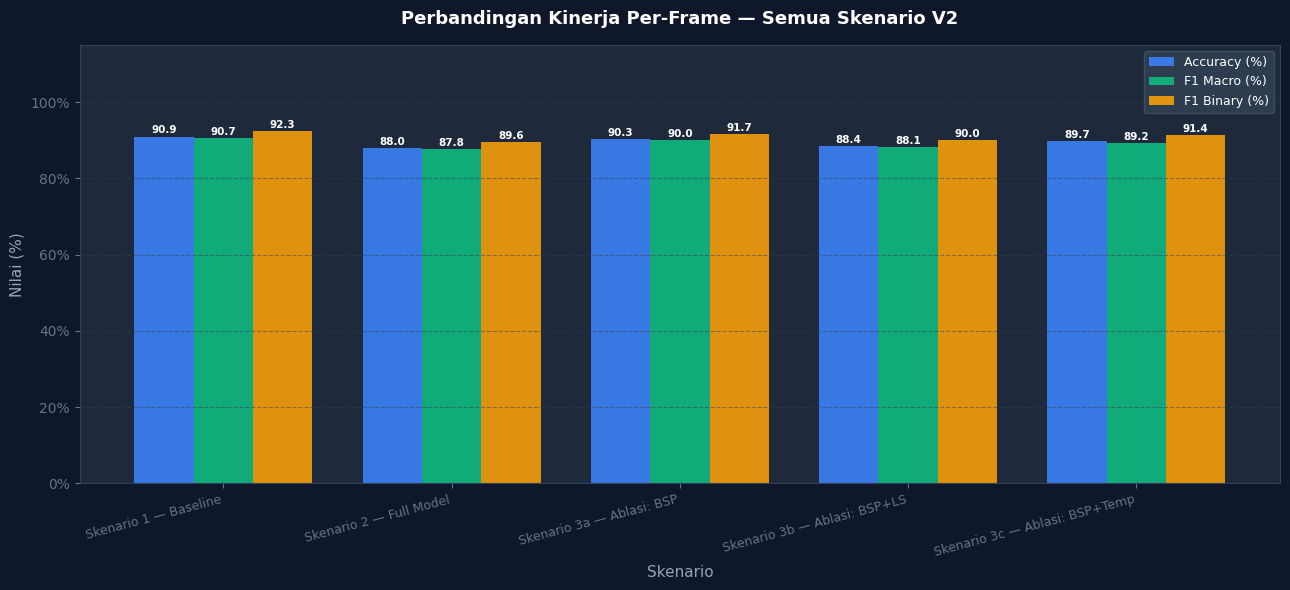

[TERSIMPAN] grafik_perbandingan_metrik_semua_skenario.png


In [7]:
# ============================================================
# Visualisasi 1: Bar Chart Perbandingan Accuracy & F1 Score
# ============================================================
label_pendek = [s.split('\n')[0] + '\n' + s.split('\n')[1]
                if '\n' in s else s for s in SKENARIO.keys()
                if any(m['Skenario'] == s.replace('\n', ' — ') for m in hasil_metrik)]

nama_skenario = [m['Skenario'] for m in hasil_metrik]
akurasi       = [m['Accuracy (%)'] for m in hasil_metrik]
f1_macro_val  = [m['F1_Macro'] * 100 for m in hasil_metrik]
f1_binary_val = [m['F1_Binary'] * 100 for m in hasil_metrik]

x = np.arange(len(nama_skenario))
lebar = 0.26

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#1e293b')

bar1 = ax.bar(x - lebar, akurasi,       lebar, label='Accuracy (%)',   color='#3b82f6', alpha=0.9)
bar2 = ax.bar(x,          f1_macro_val,  lebar, label='F1 Macro (%)',   color='#10b981', alpha=0.9)
bar3 = ax.bar(x + lebar,  f1_binary_val, lebar, label='F1 Binary (%)',  color='#f59e0b', alpha=0.9)

# Tambahkan nilai di atas batang
for bar in [bar1, bar2, bar3]:
    for rect in bar:
        h = rect.get_height()
        ax.text(rect.get_x() + rect.get_width() / 2, h + 0.3,
                f'{h:.1f}', ha='center', va='bottom', fontsize=7.5,
                color='white', fontweight='bold')

ax.set_xlabel('Skenario', fontsize=11, color='#94a3b8')
ax.set_ylabel('Nilai (%)', fontsize=11, color='#94a3b8')
ax.set_title('Perbandingan Kinerja Per-Frame — Semua Skenario V2',
             fontsize=13, fontweight='bold', color='white', pad=15)
ax.set_xticks(x)
ax.set_xticklabels([m['Skenario'] for m in hasil_metrik],
                    rotation=15, ha='right', fontsize=9, color='#e2e8f0')
ax.tick_params(colors='#64748b')
ax.set_ylim(0, 115)
ax.legend(facecolor='#334155', edgecolor='#475569', labelcolor='white', fontsize=9)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.grid(axis='y', color='#334155', linestyle='--', alpha=0.5)
ax.spines[['top','right','bottom','left']].set_color('#334155')

plt.tight_layout()
out_bar = OUTPUT_DIR / 'grafik_perbandingan_metrik_semua_skenario.png'
plt.savefig(out_bar, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'[TERSIMPAN] {out_bar.name}')

### Sel 8: Visualisasi — Heatmap Confusion Matrix Semua Skenario

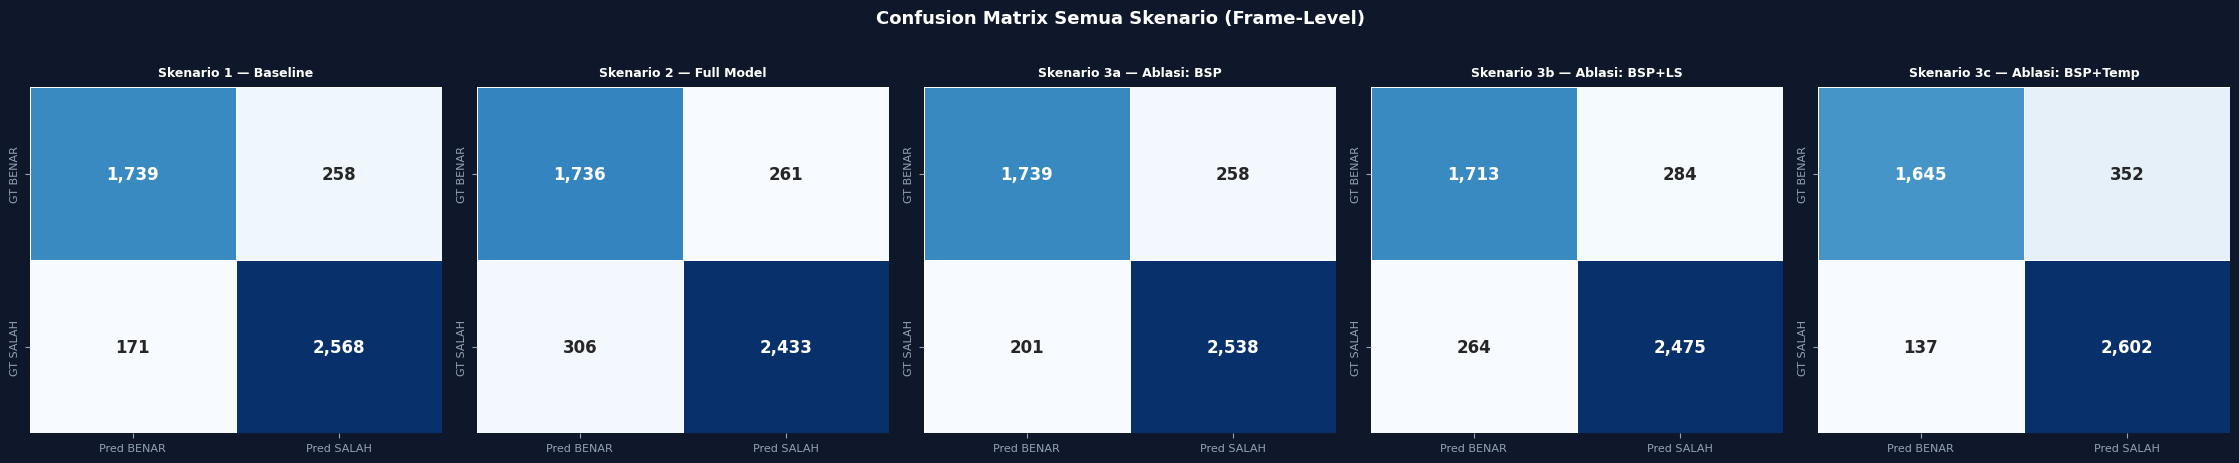

[TERSIMPAN] grafik_confusion_matrix_semua_skenario.png


In [8]:
# ============================================================
# Visualisasi 2: Heatmap Confusion Matrix setiap skenario
# ============================================================
n = len(hasil_cm)
fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5))
fig.patch.set_facecolor('#0f172a')
if n == 1:
    axes = [axes]

for ax, data in zip(axes, hasil_cm):
    matrix = np.array([[data['TN'], data['FP']],
                        [data['FN'], data['TP']]])
    sns.heatmap(
        matrix, annot=True, fmt=',d', cmap='Blues',
        xticklabels=['Pred BENAR', 'Pred SALAH'],
        yticklabels=['GT BENAR', 'GT SALAH'],
        ax=ax, linewidths=0.5, cbar=False,
        annot_kws={'size': 12, 'weight': 'bold'}
    )
    ax.set_title(data['Skenario'], fontsize=9, fontweight='bold', color='white', pad=8)
    ax.set_facecolor('#1e293b')
    ax.tick_params(colors='#94a3b8', labelsize=8)
    ax.xaxis.label.set_color('#94a3b8')
    ax.yaxis.label.set_color('#94a3b8')

fig.suptitle('Confusion Matrix Semua Skenario (Frame-Level)',
             fontsize=13, fontweight='bold', color='white', y=1.02)
plt.tight_layout()
out_cm = OUTPUT_DIR / 'grafik_confusion_matrix_semua_skenario.png'
plt.savefig(out_cm, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'[TERSIMPAN] {out_cm.name}')

### Sel 9: Visualisasi — Top 10 Bobot Atensi Sendi per Skenario

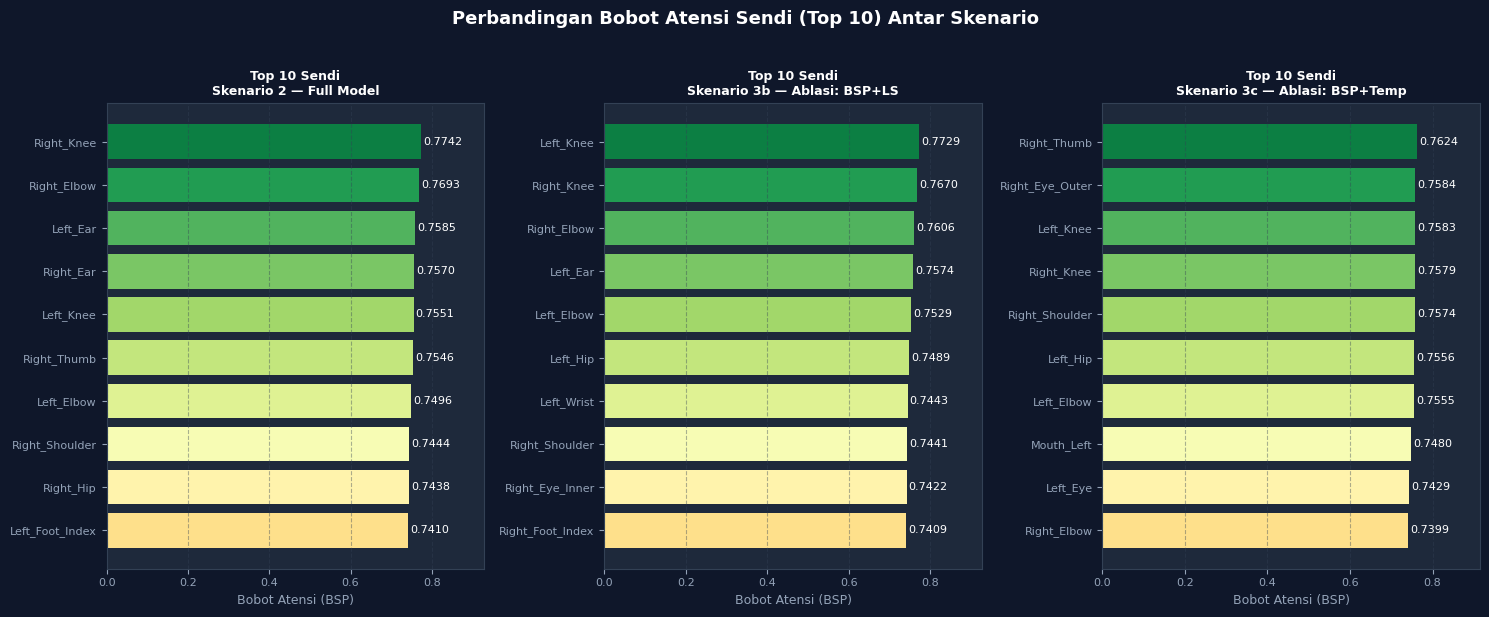

[TERSIMPAN] grafik_bobot_atensi_semua_skenario.png


In [9]:
# ============================================================
# Visualisasi 3: Bar Chart Bobot Atensi Sendi (hanya skenario dengan BSP)
# Menampilkan TOP 10 sendi dengan bobot atensi tertinggi per skenario
# ============================================================
if not hasil_atensi:
    print('Tidak ada data bobot atensi (tidak ada skenario dengan BSP aktif).')
else:
    df_aten = pd.DataFrame(hasil_atensi)
    skenario_bsp = df_aten['Skenario'].unique()
    n = len(skenario_bsp)

    fig, axes = plt.subplots(1, n, figsize=(5 * n, 6), sharey=False)
    fig.patch.set_facecolor('#0f172a')
    if n == 1:
        axes = [axes]

    warna_map = plt.cm.RdYlGn_r

    for ax, skn in zip(axes, skenario_bsp):
        subset = df_aten[df_aten['Skenario'] == skn].sort_values('Bobot', ascending=False).head(10)
        warna  = warna_map(np.linspace(0.05, 0.6, len(subset)))

        ax.set_facecolor('#1e293b')
        bars = ax.barh(subset['Nama_Sendi'][::-1], subset['Bobot'][::-1], color=warna[::-1])

        for bar, val in zip(bars, subset['Bobot'][::-1]):
            ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.4f}', va='center', fontsize=8, color='white')

        ax.set_title(f'Top 10 Sendi\n{skn}', fontsize=9, fontweight='bold', color='white')
        ax.set_xlabel('Bobot Atensi (BSP)', fontsize=9, color='#94a3b8')
        ax.tick_params(colors='#94a3b8', labelsize=8)
        ax.set_xlim(0, subset['Bobot'].max() * 1.2)
        ax.spines[['top','right','bottom','left']].set_color('#334155')
        ax.grid(axis='x', color='#334155', linestyle='--', alpha=0.4)

    fig.suptitle('Perbandingan Bobot Atensi Sendi (Top 10) Antar Skenario',
                 fontsize=13, fontweight='bold', color='white', y=1.02)
    plt.tight_layout()
    out_attn = OUTPUT_DIR / 'grafik_bobot_atensi_semua_skenario.png'
    plt.savefig(out_attn, dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.show()
    print(f'[TERSIMPAN] {out_attn.name}')